<a href="https://colab.research.google.com/github/YamiMegersa/2800269-portfolio/blob/main/ML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the plotting, seaborn libraries and the training data with labels. And merging training data with label

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# List the contents of the SharedDrives directory to see available shared drives
# This will show you the names of the shared drives you have access to.
import os

shared_drives_path = '/content/drive/SharedDrives/'
if os.path.exists(shared_drives_path):
    print("Available Shared Drives:")
    for drive_name in os.listdir(shared_drives_path):
        print(f"- {drive_name}")
else:
    print(f"The directory {shared_drives_path} does not exist. Please ensure your Google Drive is mounted correctly and you have access to shared drives.")

# Example of how to access a specific shared drive (replace 'Your Shared Drive Name' with the actual name)
# try:
#     specific_shared_drive_path = os.path.join(shared_drives_path, 'Your Shared Drive Name')
#     if os.path.exists(specific_shared_drive_path):
#         print(f"\nContents of 'Your Shared Drive Name':")
#         for item in os.listdir(specific_shared_drive_path):
#             print(f"  - {item}")
#     else:
#         print(f"\nShared Drive 'Your Shared Drive Name' not found.")
# except Exception as e:
#     print(f"An error occurred while accessing the shared drive: {e}")

The directory /content/drive/SharedDrives/ does not exist. Please ensure your Google Drive is mounted correctly and you have access to shared drives.


In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp #we will use signal for butterworth low-pass filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler #for scaling components so large values do not dominate

df = pd.read_parquet('/content/drive/Shareddrives/ML_Assignment2/test_data.parquet')
labels = pd.read_csv('/content/drive/Shareddrives/ML_Assignment2/train_labels.csv')

df = df.merge(labels, on='Sample_ID')

In [ ]:
print(df.columns.tolist())

['Sample_ID', 'Time_Step', 'Signal_M', 'Signal_B', 'Signal_J', 'Signal_H', 'Signal_L', 'Signal_F', 'Signal_D', 'Signal_A', 'Signal_G', 'Signal_K', 'Signal_C', 'Signal_E', 'Signal_I', 'Signal_N', 'class_label']


Below is a plotting function to assist in understanding the datas

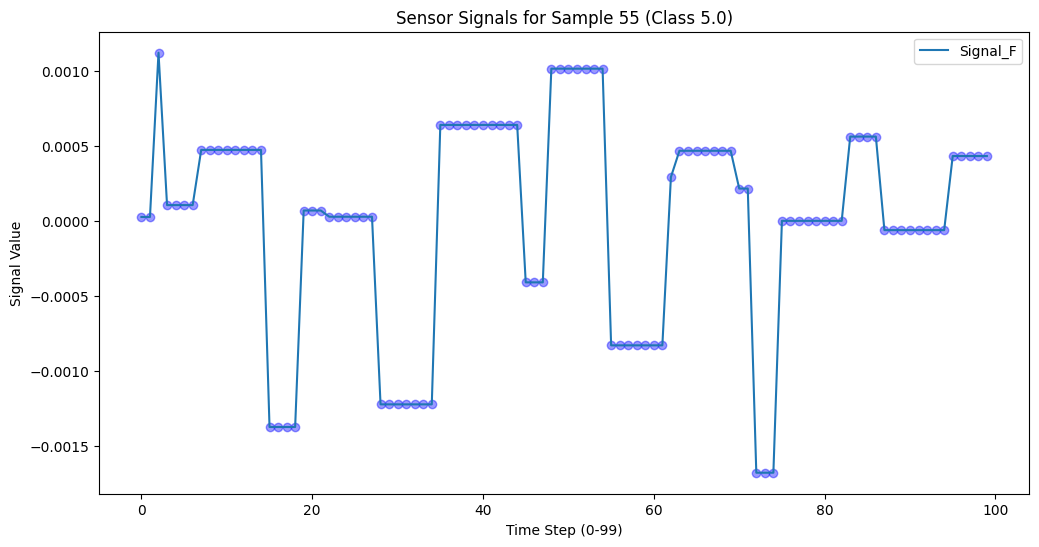

In [ ]:
sample_id = 55
sample_data = df[df['Sample_ID'] == sample_id]

plt.figure(figsize=(12, 6))

for signal in ['Signal_F']:
    plt.plot(sample_data['Time_Step'], sample_data[signal], label=signal)
    plt.scatter(sample_data['Time_Step'],sample_data[signal],color='blue',marker='o',alpha=0.4)

plt.title(f"Sensor Signals for Sample {sample_id} (Class {sample_data['class_label'].iloc[0]})")
plt.xlabel("Time Step (0-99)")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

Below is the implementation of the butterworth lowpass filter. We have a sampling rate of 333.33 (100/0.3s) since we take 100 snapshots in each 300ms timeframe. We use a cut off frequency of 10 for now so we don't cut normal human deviations. We will use a 3rd order butterworth pass so we aren't tapering too aggressively.

In [ ]:
def apply_lowpass_filter(data, cutoff_freq=18, fs=333.33, order=3):
    #Nyquist Frequency(half sample rate)
    nyquist = 0.5 * fs
    # The butterworth function wants it normalised wrt nyquist
    normal_cutoff = cutoff_freq / nyquist

    # We make the lowpass filter non-analog since discrete, this function gives us paramaters for the filter
    b, a = sp.signal.butter(N=order, Wn=normal_cutoff, btype='low', analog=False)

    #Forward-Backward filtering to reduce the phase shift introduced by the order
    filtered_signal = sp.signal.filtfilt(b, a, data)

    return filtered_signal

The code below visualises the impact of the lowpass filter on individual readings

/tmp/ipykernel_23355/4286438303.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['Signal_B_BW'] = apply_lowpass_filter(sample_data['Signal_B'])


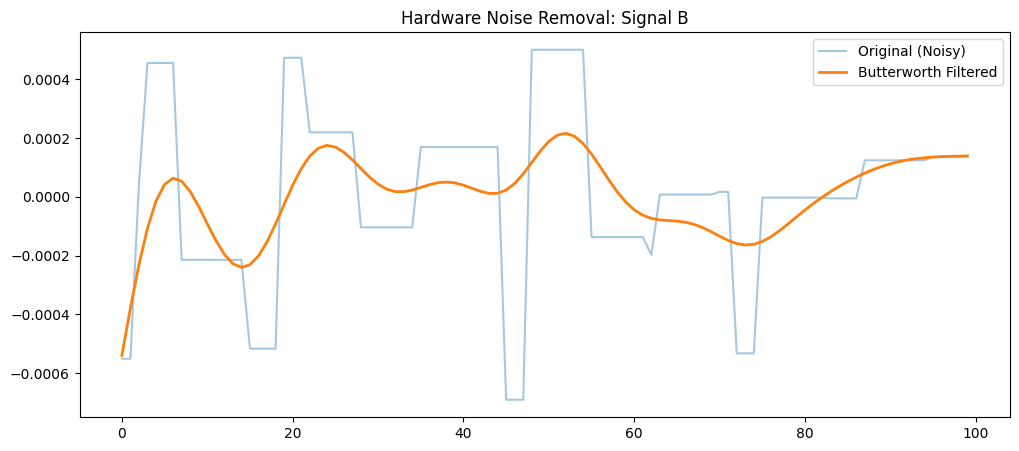

In [ ]:
sample_data['Signal_B_BW'] = apply_lowpass_filter(sample_data['Signal_B'])

# Visualize the 'ass' data vs the clean data
plt.figure(figsize=(12, 5))
plt.plot(sample_data['Time_Step'], sample_data['Signal_B'], label='Original (Noisy)', alpha=0.4)
plt.plot(sample_data['Time_Step'], sample_data['Signal_B_BW'], label='Butterworth Filtered', linewidth=2)
plt.legend()
plt.title("Hardware Noise Removal: Signal B")
plt.show()

We must now reduce dimensionality of 100 entries per feature. I say we extract the peaks and troughs of each feature after the butterworth filter.

In [ ]:
import numpy as np
from scipy.signal import find_peaks

def extract_topographic_features(sample_subset, signal_col, max_peaks=4):
    # 1. Extract raw arrays
    x_time = sample_subset['Time_Step'].values
    y_signal = sample_subset[signal_col].values

    # 2. Find unconstrained peaks
    pos_peaks, _ = find_peaks(y_signal)
    neg_peaks, _ = find_peaks(-y_signal)

    # --- Helper logic to sort and format ---
    def process_peaks(peak_indices, is_positive):
        if len(peak_indices) == 0:
            # Return zeros for both Amplitude and Time_Step if no peaks exist
            return [0, 0] * max_peaks

        amplitudes = y_signal[peak_indices]
        times = x_time[peak_indices]

        # Sort indices: highest positive peaks first, or deepest negative troughs first
        if is_positive:
            sort_order = np.argsort(amplitudes)[::-1]
        else:
            sort_order = np.argsort(amplitudes)

        sorted_amps = amplitudes[sort_order]
        sorted_times = times[sort_order]

        # Build the fixed-width array
        features = []
        for i in range(max_peaks):
            if i < len(sorted_amps):
                features.extend([sorted_amps[i], sorted_times[i]])
            else:
                features.extend([0, 0]) # Zero-padding
        return features

    # 3. Process both sets
    pos_features = process_peaks(pos_peaks, is_positive=True)
    neg_features = process_peaks(neg_peaks, is_positive=False)

    # Return a flat list of 12 features (if max_peaks=3):
    # [Pos1_Amp, Pos1_Time, Pos2_Amp, Pos2_Time... Neg1_Amp, Neg1_Time...]
    return pos_features + neg_features


Below is a visualisation of the extraction of the features

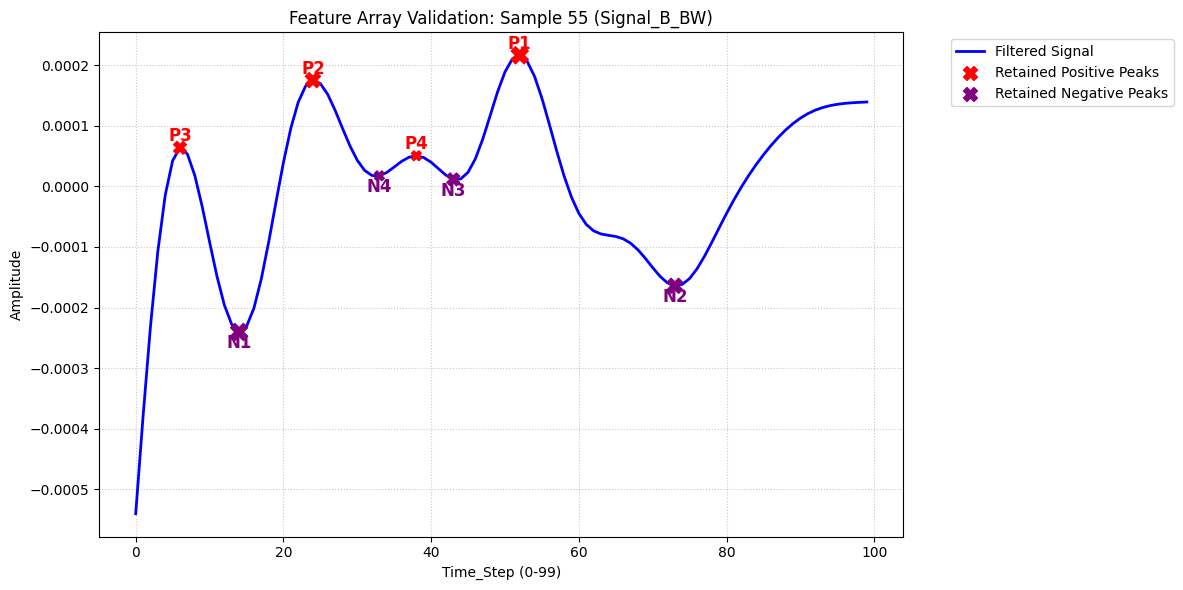

In [ ]:

def visualize_extracted_features(sample_subset, features_array, signal_col='Signal_B_BW', max_peaks=3):
    # Extract the base continuous data
    x_time = sample_subset['Time_Step'].values
    y_signal = sample_subset[signal_col].values

    plt.figure(figsize=(12, 6))
    plt.plot(x_time, y_signal, color='blue', linewidth=2, label='Filtered Signal')

    # Split the flat array into positive and negative sections
    pos_features = features_array[:max_peaks * 2]
    neg_features = features_array[max_peaks * 2:]

    # --- Plot Positive Peaks ---
    pos_times = []
    pos_amps = []
    for i in range(0, len(pos_features), 2):
        amp = pos_features[i]
        time = pos_features[i+1]
        # Ignore zero-padding
        if amp != 0 or time != 0:
            pos_amps.append(amp)
            pos_times.append(time)
            # Label them P1, P2... to verify sorting order
            rank = (i // 2) + 1
            plt.text(time, amp + (y_signal.max() * 0.05), f"P{rank}", color='red', fontsize=12, ha='center', fontweight='bold')

    if pos_times:
        # Size array makes P1 larger than P2
        sizes = np.linspace(150, 50, len(pos_times))
        plt.scatter(pos_times, pos_amps, color='red', marker='X', s=sizes, zorder=5, label='Retained Positive Peaks')

    # --- Plot Negative Peaks ---
    neg_times = []
    neg_amps = []
    for i in range(0, len(neg_features), 2):
        amp = neg_features[i]
        time = neg_features[i+1]
        if amp != 0 or time != 0:
            neg_amps.append(amp)
            neg_times.append(time)
            rank = (i // 2) + 1
            plt.text(time, amp - (abs(y_signal.min()) * 0.05), f"N{rank}", color='purple', fontsize=12, ha='center', fontweight='bold')

    if neg_times:
        sizes = np.linspace(150, 50, len(neg_times))
        plt.scatter(neg_times, neg_amps, color='purple', marker='X', s=sizes, zorder=5, label='Retained Negative Peaks')

    sample_id = sample_subset['Sample_ID'].iloc[0]
    plt.title(f"Feature Array Validation: Sample {sample_id} ({signal_col})")
    plt.xlabel("Time_Step (0-99)")
    plt.ylabel("Amplitude")

    # Place legend outside the plot to avoid covering peaks
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Generate the features using your function
features = extract_topographic_features(sample_data, signal_col='Signal_B_BW', max_peaks=4)

# Pass the resulting array into the visualization function
visualize_extracted_features(sample_data, features, signal_col='Signal_B_BW', max_peaks=4)

Implement the above on all features for all datas. We can then move on to dimensionality reduction by Principal Components.

In [ ]:
def build_feature_matrix(df,max_peaks=4):
    # Identify raw signal columns
    signal_cols = [col for col in df.columns if col.startswith('Signal_')]
    #makes the 14

    # Generate column labels based on max_peaks
    labels = []
    for i in range(1, max_peaks + 1):
        labels.extend([f'P{i}_Amp', f'P{i}_Time'])
    for i in range(1, max_peaks + 1):
        labels.extend([f'N{i}_Amp', f'N{i}_Time'])

    all_features = []

    for sample_id, group_df in tqdm(df.groupby('Sample_ID'), desc="Processing Pipeline"):
        # Copy to prevent SettingWithCopyWarning when adding filtered columns
        temp_df = group_df.copy()
        sample_dict = {'Sample_ID': sample_id}

        for sig_col in signal_cols:
            filtered_col_name = f"{sig_col}_Filtered"

            # Apply filter and store back in the dataframe
            temp_df[filtered_col_name] = apply_lowpass_filter(temp_df[sig_col])

            # Pass the dataframe and the new column name to the extractor
            features = extract_topographic_features(temp_df, filtered_col_name)

            # Map features to column names
            for idx, label in enumerate(labels):
                sample_dict[f"{sig_col}_{label}"] = features[idx]

        all_features.append(sample_dict)

    return pd.DataFrame(all_features)

In [ ]:
X_train_features = build_feature_matrix(df, max_peaks=4)

Processing Pipeline:   0%|          | 0/2793 [00:00<?, ?it/s]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate features from the identifier
feature_cols = [col for col in X_train_features.columns if col != 'Sample_ID']
X_raw = X_train_features[feature_cols].values

#Gaussian normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw) #Z-score normalisation for no scale dominance

# 3. Apply PCA with 90% explanatory power. We can tweak this later
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Reconstruct the DataFrame
pca_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Reattach the Sample_ID so you can merge with your labels later
X_pca_df.insert(0, 'Sample_ID', X_train_features['Sample_ID'].values)

print(f"Original Feature Count: {X_raw.shape[1]}")
print(f"Reduced Principal Components: {X_pca.shape[1]}")

Original Feature Count: 224
Reduced Principal Components: 121
